# День 7 — Финализация mini-product

Сводка по всему проекту: полный цикл **data → preprocessing → baseline → improvement → error analysis → inference**.

Полное описание — в корневом [README](../README.md).

In [1]:
import sys, os
# Добавляем корень проекта в путь, чтобы импортировать модули (config, preprocess, ...)
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from pathlib import Path
from IPython.display import Image, display
from config import REPORTS_DIR

## 1. Baseline

In [3]:
print((REPORTS_DIR / 'baseline_result.txt').read_text(encoding='utf-8'))

=== Baseline: TF-IDF (1,2) + LogisticRegression(max_iter=200, n_jobs=-1) ===
Train size: 4257, Test size: 1065

              precision    recall  f1-score   support

    negative     0.6000    0.1780    0.2745       118
     neutral     0.7561    0.9201    0.8301       576
    positive     0.7356    0.6523    0.6914       371

    accuracy                         0.7446      1065
   macro avg     0.6972    0.5835    0.5987      1065
weighted avg     0.7316    0.7446    0.7202      1065

Baseline macro F1: 0.5987



## 2. Сравнение подходов

In [4]:
print((REPORTS_DIR / 'improvement_comparison.txt').read_text(encoding='utf-8'))

=== День 4 — сравнение подходов (один и тот же test set) ===

| Метод | Macro F1 | Улучшение |
|-------|----------|-----------|
| Baseline: TF-IDF(1,2) + LogReg | 0.5987 | - |
| TF-IDF(1,3) + LinearSVC | 0.6646 | +6.59% |
| TF-IDF(1,2) sublinear + LogReg | 0.6948 | +9.61% |
| Word+Char TF-IDF + LinearSVC | 0.6800 | +8.13% |
| TF-IDF(1,2) + RandomForest | 0.5609 | -3.78% |
| Lemmatization(spacy) + TF-IDF + LogReg | 0.7147 | +11.60% |
| Word+Char + LinearSVC (tuned C=0.5) | 0.6983 | +9.96% |

Лучший метод: Lemmatization(spacy) + TF-IDF + LogReg (macro F1 = 0.7147, +11.60% к baseline).

Что помогло: лемматизация (spacy) схлопывает формы слов и уменьшает разреженность, а class_weight='balanced' поднимает recall редкого класса negative — их сочетание дало лучший результат. Символьные n-граммы и sublinear_tf тоже прибавляют. Что не помогло: RandomForest (склонен к majority-классу neutral на разреженных TF-IDF, худший результат) и триграммы отдельно.


## 3. Error analysis

In [5]:
print((REPORTS_DIR / 'error_analysis.txt').read_text(encoding='utf-8'))

=== День 5 — Error analysis (best model) ===

Всего в test: 1065, ошибок: 251 (23.6%)

Classification report:
              precision    recall  f1-score   support

    negative     0.5263    0.6780    0.5926       118
     neutral     0.8265    0.8351    0.8307       576
    positive     0.7644    0.6819    0.7208       371

    accuracy                         0.7643      1065
   macro avg     0.7057    0.7317    0.7147      1065
weighted avg     0.7716    0.7643    0.7661      1065

Confusion matrix (строки=true, столбцы=pred):
             negative    neutral   positive
  negative         80         16         22
   neutral         39        481         56
  positive         33         85        253

Самые частые типы ошибок (true -> pred):
  positive -> neutral: 85
  neutral -> positive: 56
  neutral -> negative: 39
  positive -> negative: 33
  negative -> positive: 22
  negative -> neutral: 16

Примеры ошибок:

[positive -> neutral]
  - Last year the company raised its turnover t

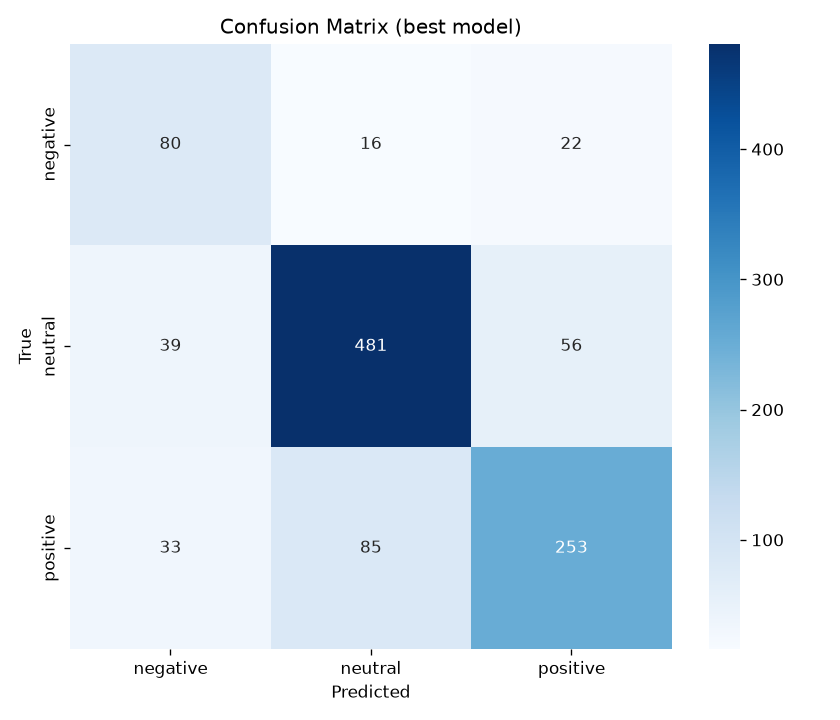

In [6]:
display(Image(str(REPORTS_DIR / 'confusion_matrix.png')))

## 4. Живой inference

In [7]:
import pandas as pd
from predict import predict_sentiment
demo = ['Profits jumped to a record high', 'The firm filed for bankruptcy', 'Results were in line with forecasts']
pd.DataFrame(predict_sentiment(demo))[['sentiment', 'confidence', 'text']]

,sentiment,confidence,text
0,positive,0.8920,Profits jumped to a record high
1,neutral,0.6283,The firm filed for bankruptcy
2,positive,0.5775,Results were in line with forecasts


## Ограничения
- Классическая модель (TF-IDF + линейный классификатор): не улавливает контекст/сарказм.
- Только английский, стиль новостных заголовков.
- `negative` предсказывается менее надёжно (дисбаланс классов).
- Не является инвестиционной рекомендацией — учебный проект.